# Import Libraries

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings                                                                      
warnings.filterwarnings('ignore')  
from IPython.display import Audio, display, Markdown
import librosa
import librosa.display
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import Audio, display

# Loading Data

## TESS Data

In [2]:
tess_path = '../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data'

In [3]:
tess_file_paths = []
tess_labels = []

for folder in os.listdir(tess_path):
    folder_path = os.path.join(tess_path, folder)
    label = folder[4:] 
    label = label.lower() 

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        tess_file_paths.append(file_path)
        tess_labels.append(label)

In [4]:
tess_data = pd.DataFrame({
    'paths' : tess_file_paths,
    'emotions' : tess_labels
})

## SAVEE Data

In [5]:
savee_path = "../Data/SAVEE data/SAVEE data"

In [6]:
savee_file_paths = []
savee_labels = []

for folder in os.listdir(savee_path):
    folder_path = os.path.join(savee_path, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.endswith(".wav"):
            filename = file.split('.')[0]
            label = ''.join(filter(str.isalpha, filename)).lower()
            file_path = os.path.join(folder_path, file)
            savee_file_paths.append(file_path)
            savee_labels.append(label)

In [7]:
savee_data = pd.DataFrame({
    'paths': savee_file_paths,
    'emotions': savee_labels
})

In [8]:
emotion_mapping = {
    'a': 'angry',
    'd': 'disgust',
    'h': 'happy',
    'sa': 'sad',
    'su': 'pleasant_surprise',
    'f': 'fearful',
    'n': 'neutral'
}

savee_data['emotions'] = savee_data['emotions'].map(emotion_mapping)

In [9]:
emotion_data = pd.concat([
    tess_data.assign(dataset='TESS'),
    savee_data.assign(dataset='SAVEE')
], ignore_index=True)

# EDA

## Sampling rate check

In [10]:
def get_sampling_rate(path):
    try:
        y, sr = librosa.load(path, sr=None)
        return sr
    except:
        return None

emotion_data['sampling_rate'] = emotion_data['paths'].apply(get_sampling_rate)

sampling_counts = emotion_data['sampling_rate'].value_counts().reset_index()
sampling_counts.columns = ['Sampling Rate (Hz)', 'Number of Files']

display(sampling_counts)

,Sampling Rate (Hz),Number of Files
0,24414,2799
1,44100,480
2,96000,1


## Audio duration check

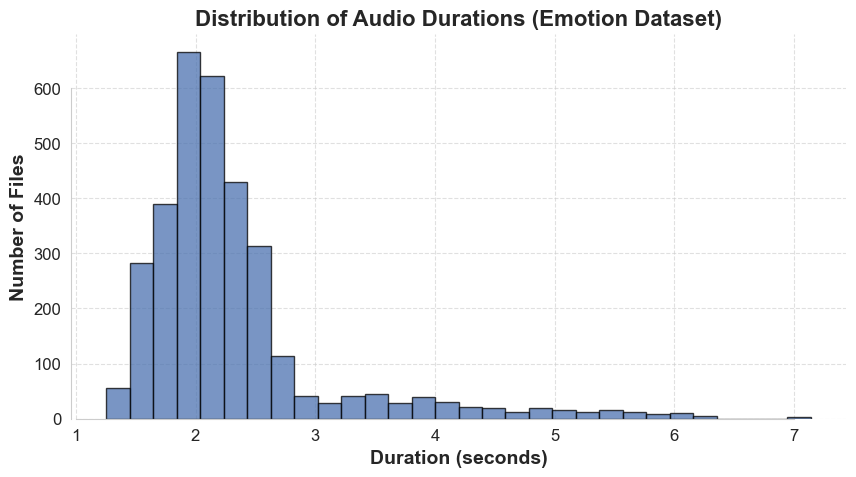

,paths,duration_sec
0,../Data/TESS Toronto emotional speech set data...,1.539035
1,../Data/TESS Toronto emotional speech set data...,1.616613
2,../Data/TESS Toronto emotional speech set data...,1.542025
3,../Data/TESS Toronto emotional speech set data...,1.606865
4,../Data/TESS Toronto emotional speech set data...,1.395183


In [11]:
durations = []

for path in emotion_data['paths']:
    y, sr = librosa.load(path, sr=None)  
    duration = librosa.get_duration(y=y, sr=sr)
    durations.append(duration)

emotion_data['duration_sec'] = durations

sns.set_style("whitegrid")

plt.figure(figsize=(10,5))

plt.hist(emotion_data['duration_sec'], bins=30, color='#4C72B0', 
         edgecolor='black', alpha=0.75)

plt.xlabel("Duration (seconds)", fontsize=14, weight='bold')
plt.ylabel("Number of Files", fontsize=14, weight='bold')
plt.title("Distribution of Audio Durations (Emotion Dataset)", fontsize=16, weight='bold')

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine(trim=True)
plt.show()

emotion_data[['paths', 'duration_sec']].head()

## Waveform analysis

In [12]:
def get_waveform_stats(path):
    try:
        y, sr = librosa.load(path, sr=None)
        return {
            "min_amp": float(np.min(y)),
            "max_amp": float(np.max(y)),
            "mean_amp": float(np.mean(y)),
            "std_amp": float(np.std(y))
        }
    except:
        return {
            "min_amp": None,
            "max_amp": None,
            "mean_amp": None,
            "std_amp": None
        }

waveform_stats = emotion_data['paths'].apply(get_waveform_stats)

waveform_df = pd.DataFrame(list(waveform_stats))

emotion_data = pd.concat([emotion_data, waveform_df], axis=1)

display(emotion_data[['paths', 'min_amp', 'max_amp', 'mean_amp', 'std_amp']].head())

,paths,min_amp,max_amp,mean_amp,std_amp
0,../Data/TESS Toronto emotional speech set data...,-0.337341,0.326202,0.000165,0.056031
1,../Data/TESS Toronto emotional speech set data...,-0.176117,0.174042,0.000053,0.028573
2,../Data/TESS Toronto emotional speech set data...,-0.265015,0.240540,0.000100,0.041019
3,../Data/TESS Toronto emotional speech set data...,-0.343719,0.314209,0.000126,0.058056
4,../Data/TESS Toronto emotional speech set data...,-0.282318,0.206024,-0.000121,0.037087


## Spectrogram analysis

,Spectrogram Frequency Bins,Number of Files
0,1025,3280


,Spectrogram Time Frames,Number of Files
0,87,95
1,86,94
2,88,87
3,90,87
4,91,84
5,84,78
6,95,78
7,85,76
8,81,74
9,93,74


,mean_db,max_db,total_energy
count,3280.000,3280.0,3.280000e+03
mean,-64.599,-0.0,5.499916e+05
std,4.738,0.0,1.774665e+06
min,-76.405,-0.0,1.688160e+03
25%,-67.018,0.0,3.262700e+04
50%,-64.060,0.0,7.526821e+04
75%,-61.422,0.0,2.196609e+05
max,-51.000,0.0,2.318936e+07



--- Emotion: angry ---
../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data\OAF_angry\OAF_pike_angry.wav


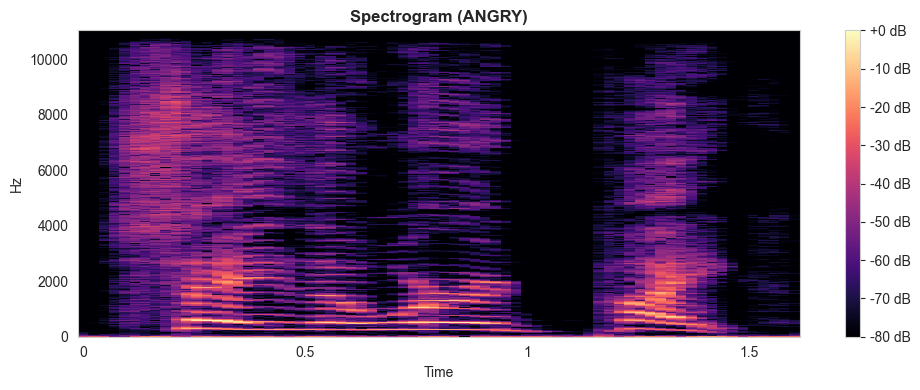


--- Emotion: disgust ---
../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data\OAF_disgust\OAF_pike_disgust.wav


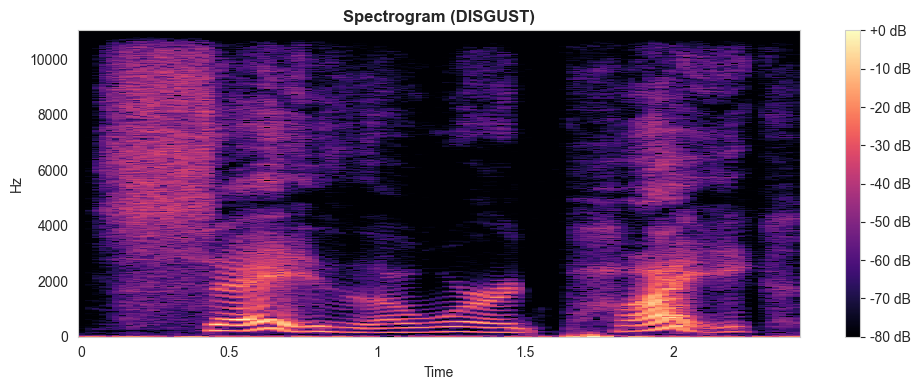


--- Emotion: fear ---
../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data\YAF_fear\YAF_book_fear.wav


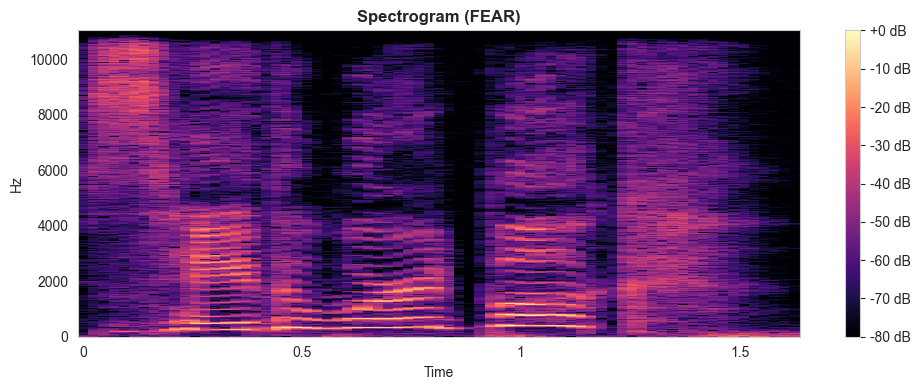


--- Emotion: happy ---
../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data\OAF_happy\OAF_pike_happy.wav


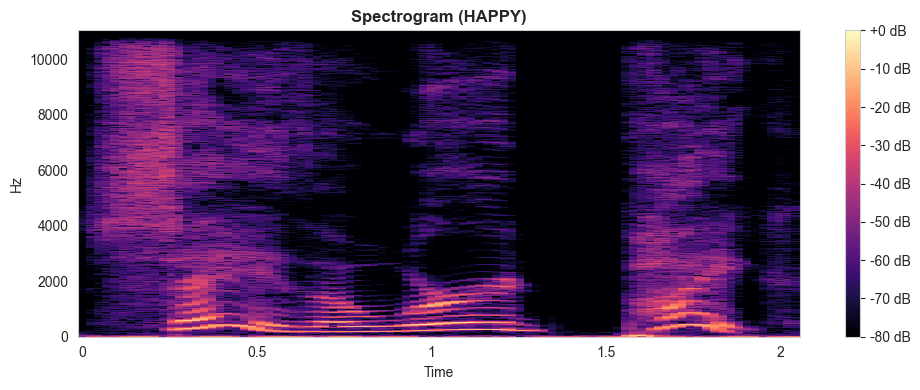


--- Emotion: neutral ---
../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data\YAF_neutral\YAF_kick_neutral.wav


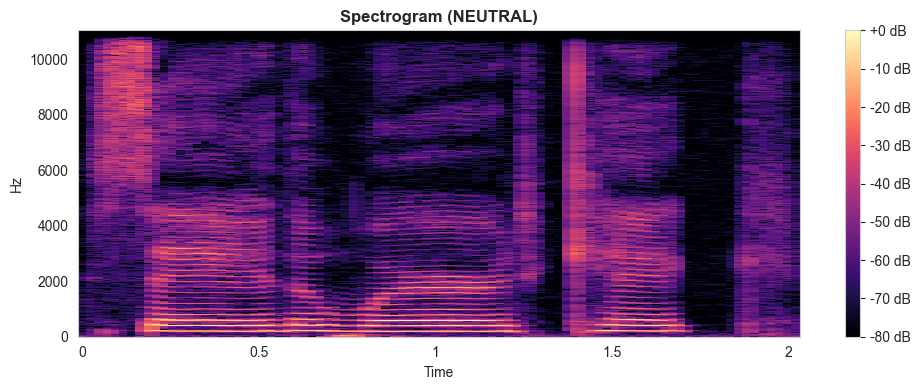


--- Emotion: pleasant_surprise ---
../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data\OAF_Pleasant_surprise\OAF_dime_ps.wav


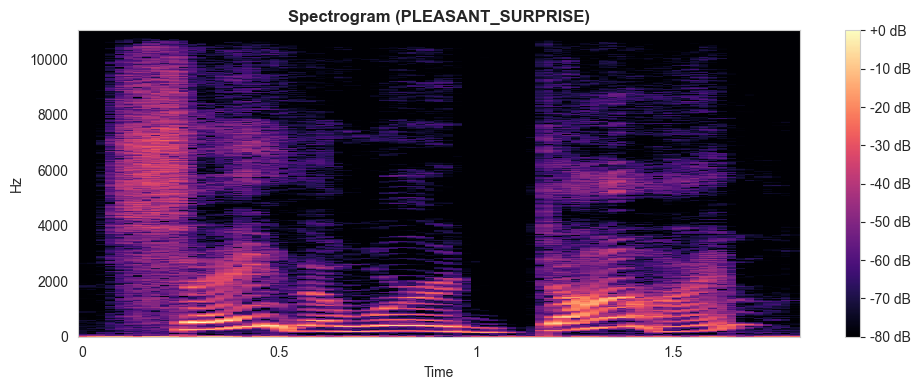


--- Emotion: sad ---
../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data\OAF_Sad\OAF_pike_sad.wav


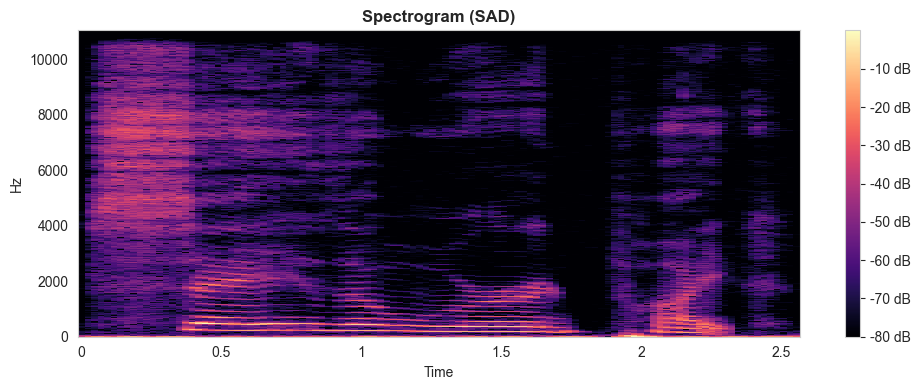


--- Emotion: pleasant_surprised ---
../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data\YAF_pleasant_surprised\YAF_luck_ps.wav


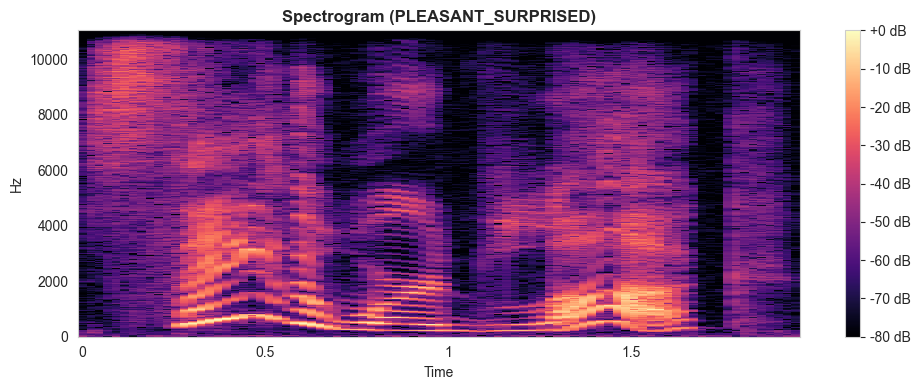


--- Emotion: fearful ---
../Data/SAVEE data/SAVEE data\DC\f01.wav


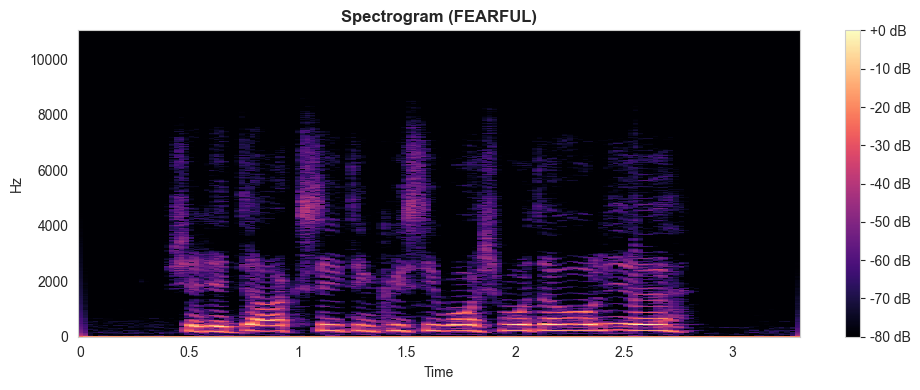

In [13]:
def get_spectrogram_stats(path, n_fft=2048, hop_length=512):
    try:
        y, sr = librosa.load(path, sr=22050)
        S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
        S_db = librosa.amplitude_to_db(S, ref=np.max)
        shape = S_db.shape               # (freq_bins, time_frames)
        mean_db = float(np.mean(S_db))
        max_db = float(np.max(S_db))
        total_energy = float(np.sum(S**2))  # raw spectral energy
        return {
            "spec_freq_bins": int(shape[0]),
            "spec_time_frames": int(shape[1]),
            "mean_db": mean_db,
            "max_db": max_db,
            "total_energy": total_energy
        }
    except Exception:
        return {
            "spec_freq_bins": None,
            "spec_time_frames": None,
            "mean_db": None,
            "max_db": None,
            "total_energy": None
        }

# Apply to combined dataset
spec_stats = emotion_data['paths'].apply(lambda p: get_spectrogram_stats(p))
spec_df = pd.DataFrame(list(spec_stats))

# Merge into emotion_data (align by index)
emotion_data = pd.concat([emotion_data.reset_index(drop=True), spec_df.reset_index(drop=True)], axis=1)

# Frequency / time-frame counts
freq_counts = emotion_data['spec_freq_bins'].value_counts().reset_index()
freq_counts.columns = ['Spectrogram Frequency Bins', 'Number of Files']

timeframe_counts = emotion_data['spec_time_frames'].value_counts().reset_index()
timeframe_counts.columns = ['Spectrogram Time Frames', 'Number of Files']

pd.set_option('display.max_rows', None)
display(freq_counts)
display(timeframe_counts)

# Summary statistics for dB and energy
display(emotion_data[['mean_db', 'max_db', 'total_energy']].describe().round(3))

# Plot function (uses emotion in title)
def plot_spectrogram(path, emotion, n_fft=2048, hop_length=512):
    y, sr = librosa.load(path, sr=22050)
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram ({emotion.upper()})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Plot one sample per emotion from the combined dataset
for emo in emotion_data['emotions'].unique():
    sample = emotion_data[emotion_data['emotions'] == emo]['paths'].sample(n=1, random_state=42).iloc[0]
    print(f"\n--- Emotion: {emo} ---\n{sample}")
    plot_spectrogram(sample, emo)

## MFCC 

In [14]:
def get_mfcc_size(path, n_mfcc=40):
    try:
        y, sr = librosa.load(path, sr=22050)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return mfcc.shape[0]     # number of MFCC coefficients
    except:
        return None

emotion_data['mfcc_size'] = emotion_data['paths'].apply(get_mfcc_size)

mfcc_counts = emotion_data['mfcc_size'].value_counts().reset_index()
mfcc_counts.columns = ['MFCC Feature Count', 'Number of Files']

display(mfcc_counts)

,MFCC Feature Count,Number of Files
0,40,3280


## Chroma STFT

In [15]:
def get_chroma_size(path):
    try:
        y, sr = librosa.load(path, sr=22050)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        return chroma.shape[0]     
    except:
        return None

emotion_data['chroma_size'] = emotion_data['paths'].apply(get_chroma_size)

chroma_counts = emotion_data['chroma_size'].value_counts().reset_index()
chroma_counts.columns = ['Chroma Feature Count', 'Number of Files']

display(chroma_counts)

,Chroma Feature Count,Number of Files
0,12,3280


## Mel Spectrogram

In [16]:
def get_mel_size(path, n_mels=128):
    try:
        y, sr = librosa.load(path, sr=22050)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        return mel.shape[0]     
    except:
        return None

emotion_data['mel_size'] = emotion_data['paths'].apply(get_mel_size)

mel_counts = emotion_data['mel_size'].value_counts().reset_index()
mel_counts.columns = ['Mel Feature Count', 'Number of Files']

display(mel_counts)

,Mel Feature Count,Number of Files
0,128,3280


## Pitch

Pitch Summary Statistics (emotion_data):


,Value
count,3280.00
mean,235.38
std,42.04
min,126.75
25%,207.85
50%,232.79
75%,268.22
max,353.01


Pitch Bucket Table (emotion_data):


,Pitch Range (Hz),Number of Files
0,0–100,0
1,100–200,587
2,200–300,2512
3,300–400,181
4,400–500,0


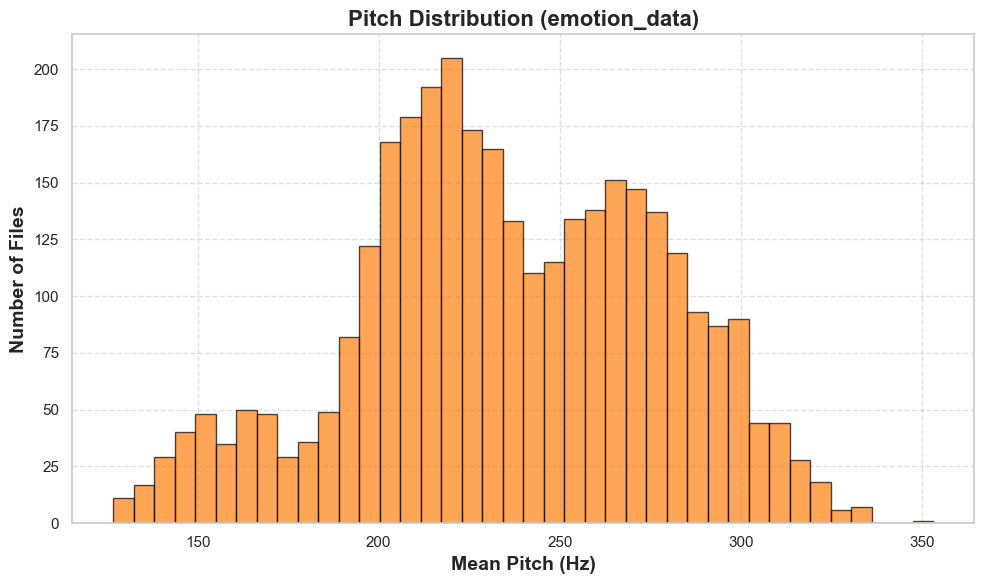

In [17]:
def get_mean_pitch(path, sr=22050, fmin=50, fmax=500):
    try:
        y, sr = librosa.load(path, sr=sr)
        f0 = librosa.yin(y, fmin=fmin, fmax=fmax, sr=sr)
        f0 = f0[~np.isnan(f0)]
        if len(f0) == 0:
            return np.nan
        return float(np.mean(f0))
    except:
        return np.nan

emotion_data['mean_pitch'] = emotion_data['paths'].apply(get_mean_pitch)

pitch_summary = emotion_data['mean_pitch'].describe().round(2)
pitch_summary_df = pd.DataFrame(pitch_summary)
pitch_summary_df.columns = ['Value']

print("Pitch Summary Statistics (emotion_data):")
display(pitch_summary_df)

pitch_buckets = pd.cut(
    emotion_data['mean_pitch'].fillna(0),
    bins=[0,100,200,300,400,500],
    labels=['0–100', '100–200', '200–300', '300–400', '400–500']
).value_counts().sort_index()

pitch_bucket_df = pitch_buckets.reset_index()
pitch_bucket_df.columns = ['Pitch Range (Hz)', 'Number of Files']

print("Pitch Bucket Table (emotion_data):")
display(pitch_bucket_df)

sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
plt.hist(emotion_data['mean_pitch'].dropna(), bins=40, color='#FF7F0E', edgecolor='black', alpha=0.7)

plt.xlabel('Mean Pitch (Hz)', fontsize=14, weight='bold')
plt.ylabel('Number of Files', fontsize=14, weight='bold')
plt.title('Pitch Distribution (emotion_data)', fontsize=16, weight='bold')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Class imbalance check

,Emotion,Number of Files,Percent
0,neutral,520,15.85
1,angry,460,14.02
2,disgust,460,14.02
3,happy,460,14.02
4,sad,460,14.02
5,fear,400,12.20
6,pleasant_surprise,260,7.93
7,pleasant_surprised,200,6.10
8,fearful,60,1.83


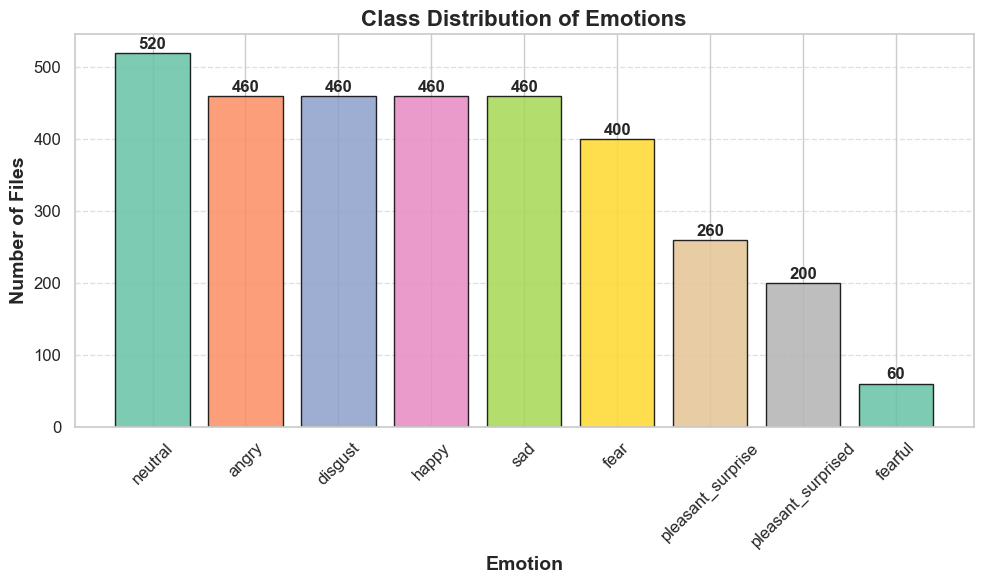

In [18]:
class_counts = emotion_data['emotions'].value_counts().reset_index()
class_counts.columns = ['Emotion', 'Number of Files']

class_counts['Percent'] = (class_counts['Number of Files'] / class_counts['Number of Files'].sum() * 100).round(2)
display(class_counts)

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

colors = sns.color_palette("Set2", len(class_counts))

bars = plt.bar(class_counts['Emotion'], class_counts['Number of Files'],
               color=colors, edgecolor='black', alpha=0.85)

plt.xlabel('Emotion', fontsize=14, weight='bold')
plt.ylabel('Number of Files', fontsize=14, weight='bold')
plt.title('Class Distribution of Emotions', fontsize=16, weight='bold')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, f'{int(height)}',
             ha='center', va='bottom', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

## Analysing Emotion Counts and Percentages

,Emotion,Count,Percent (%)
0,neutral,520,15.85
1,angry,460,14.02
2,disgust,460,14.02
3,happy,460,14.02
4,sad,460,14.02
5,fear,400,12.20
6,pleasant_surprise,260,7.93
7,pleasant_surprised,200,6.10
8,fearful,60,1.83


Unique Labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'pleasant_surprise' 'sad'
 'pleasant_surprised' 'fearful']


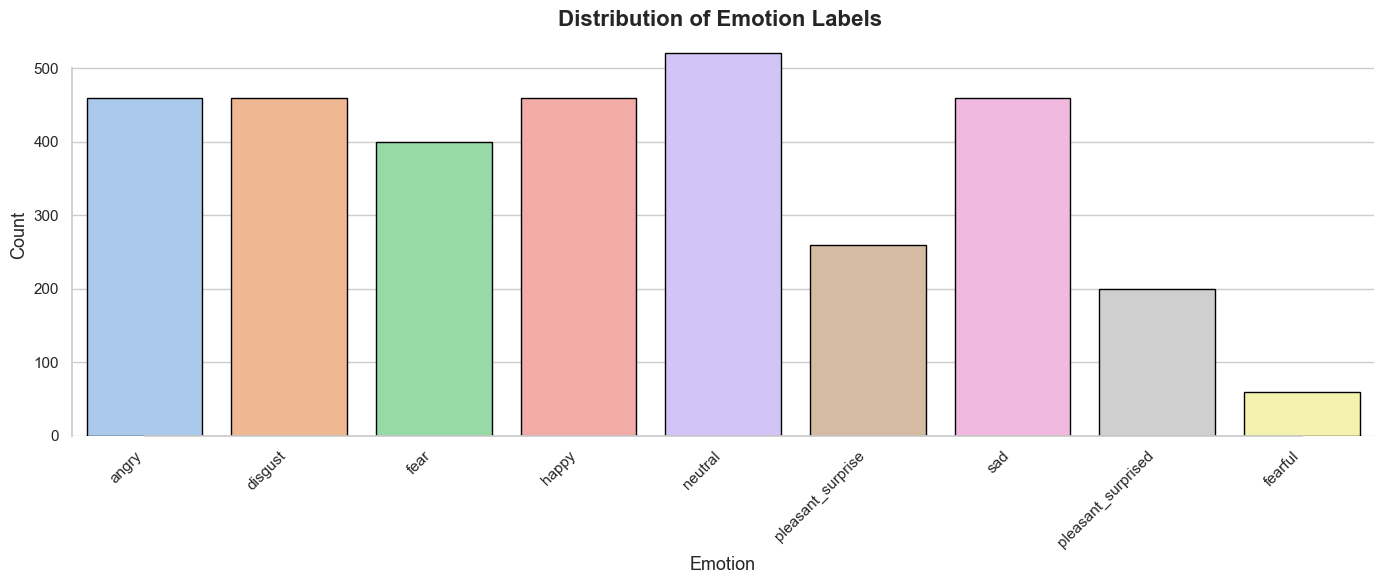

In [19]:
# Emotion label EDA for the combined dataset (emotion_data)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Combined table: Count + Percent
emotion_summary = (
    emotion_data['emotions']
    .value_counts()
    .reset_index()
)

emotion_summary.columns = ['Emotion', 'Count']
emotion_summary['Percent (%)'] = (
    emotion_summary['Count'] / emotion_summary['Count'].sum() * 100
).round(2)

display(emotion_summary)

# Unique labels
print("Unique Labels:", emotion_data['emotions'].unique())

# Plot (styled like your TESS plot)
sns.set(style="whitegrid")
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12
})

plt.figure(figsize=(14, 6))
palette = sns.color_palette("pastel", emotion_summary.shape[0])

sns.countplot(
    x='emotions',
    data=emotion_data,
    palette=palette,
    edgecolor='black'
)

plt.title("Distribution of Emotion Labels ", fontsize=16, fontweight='bold')
plt.xlabel("Emotion", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=11)

sns.despine(trim=True)
plt.tight_layout()
plt.show()


# Visualizing Class Distributions in the TESS Dataset

,Emotion,Files,Mean Duration (s),Mean Pitch (Hz),Min Duration,Max Duration
0,angry,460,2.09,243.38,1.29,7.02
1,disgust,460,2.65,205.04,1.85,7.01
2,fear,400,1.66,290.30,1.25,2.06
3,fearful,60,3.75,190.66,1.81,5.91
4,happy,460,2.21,256.42,1.63,5.97
5,neutral,520,2.41,201.21,1.65,6.16
6,pleasant_surprise,260,2.45,238.65,1.68,6.29
7,pleasant_surprised,200,1.97,282.97,1.65,2.45
8,sad,460,2.67,210.84,1.77,7.14


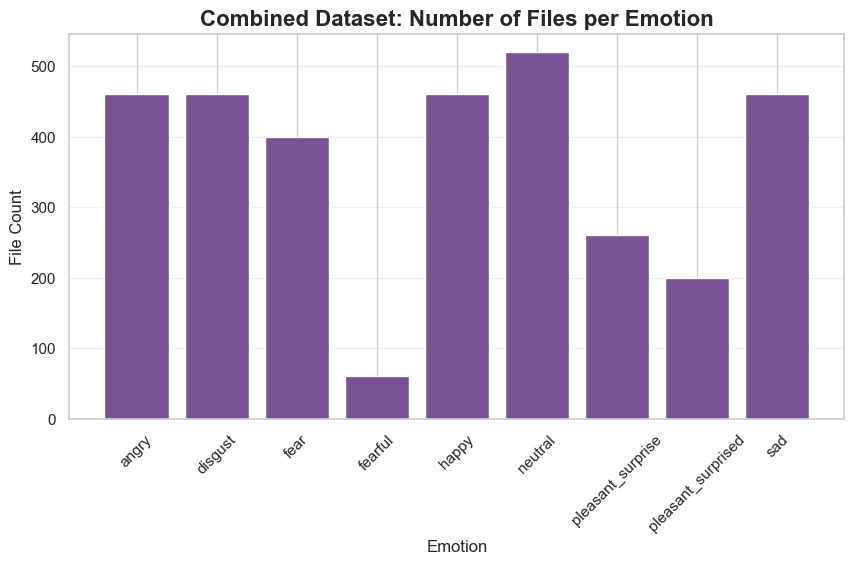

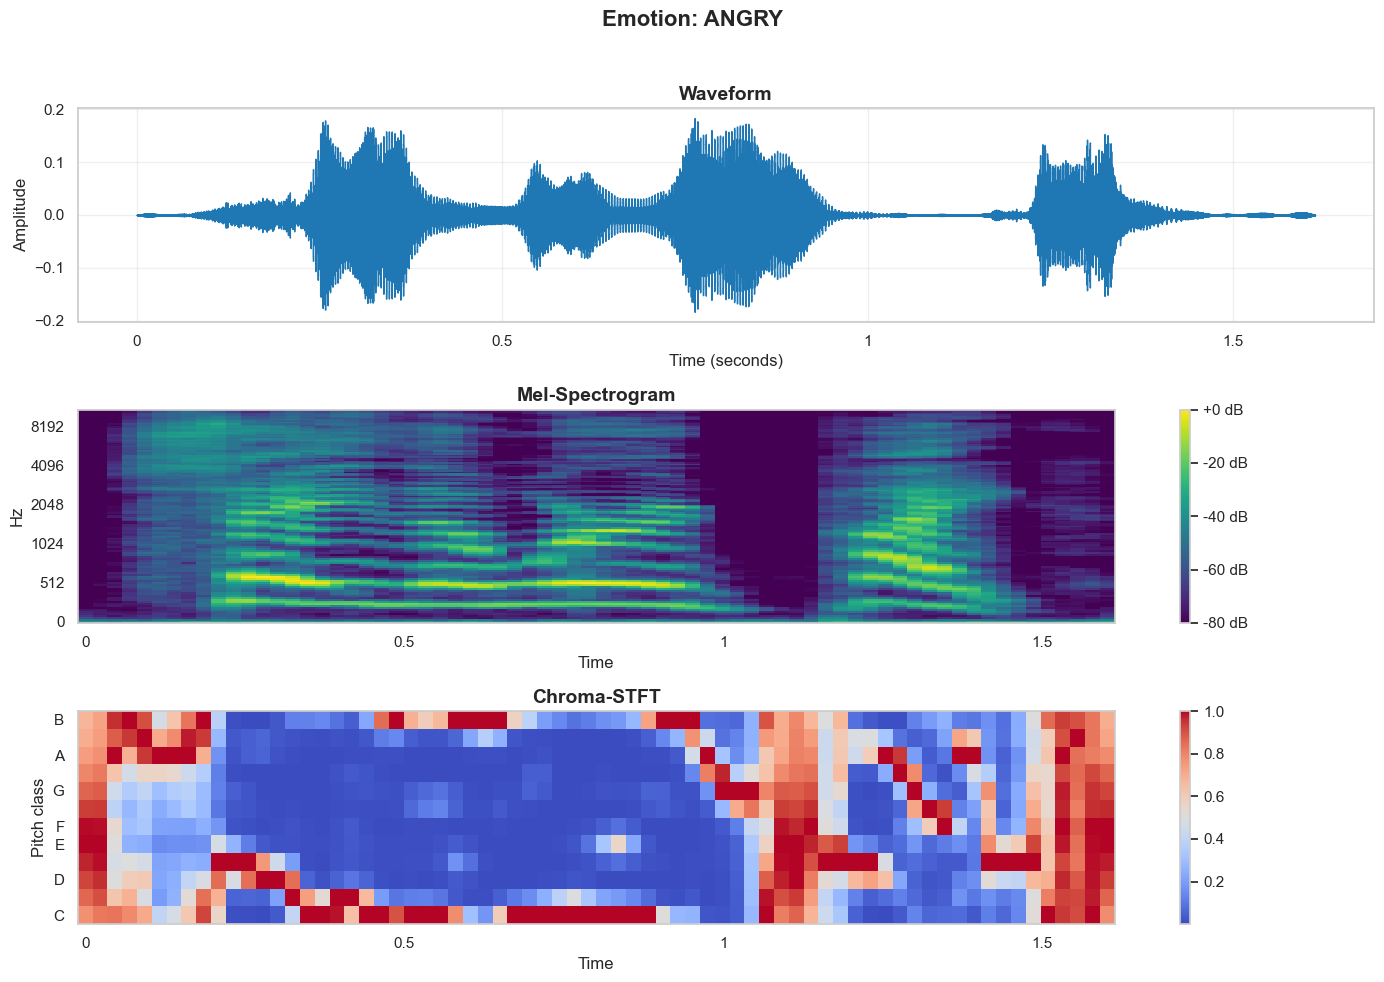

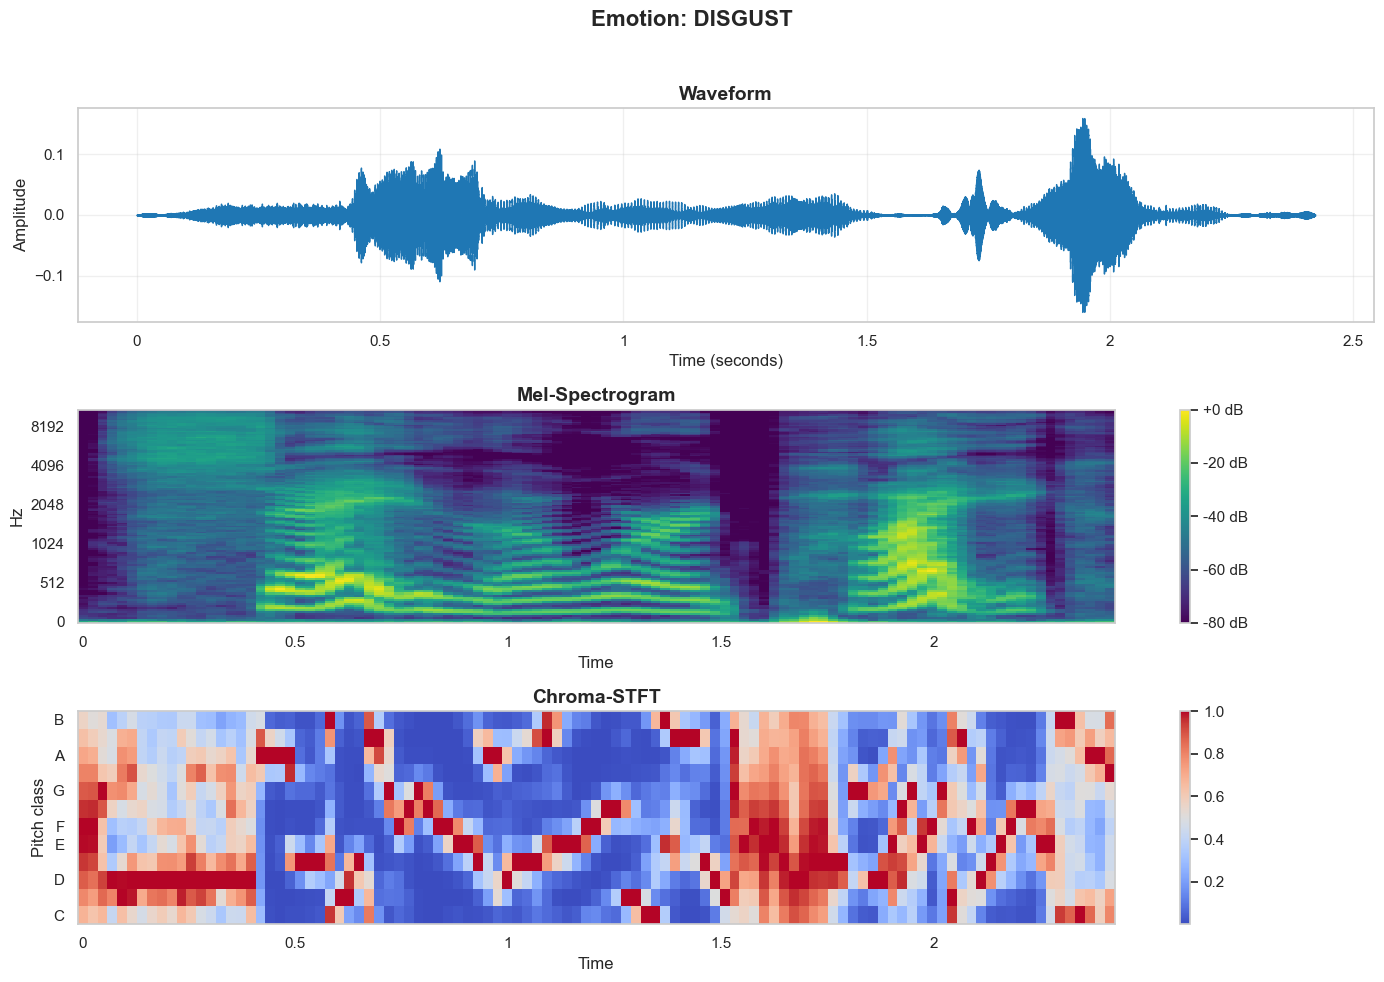

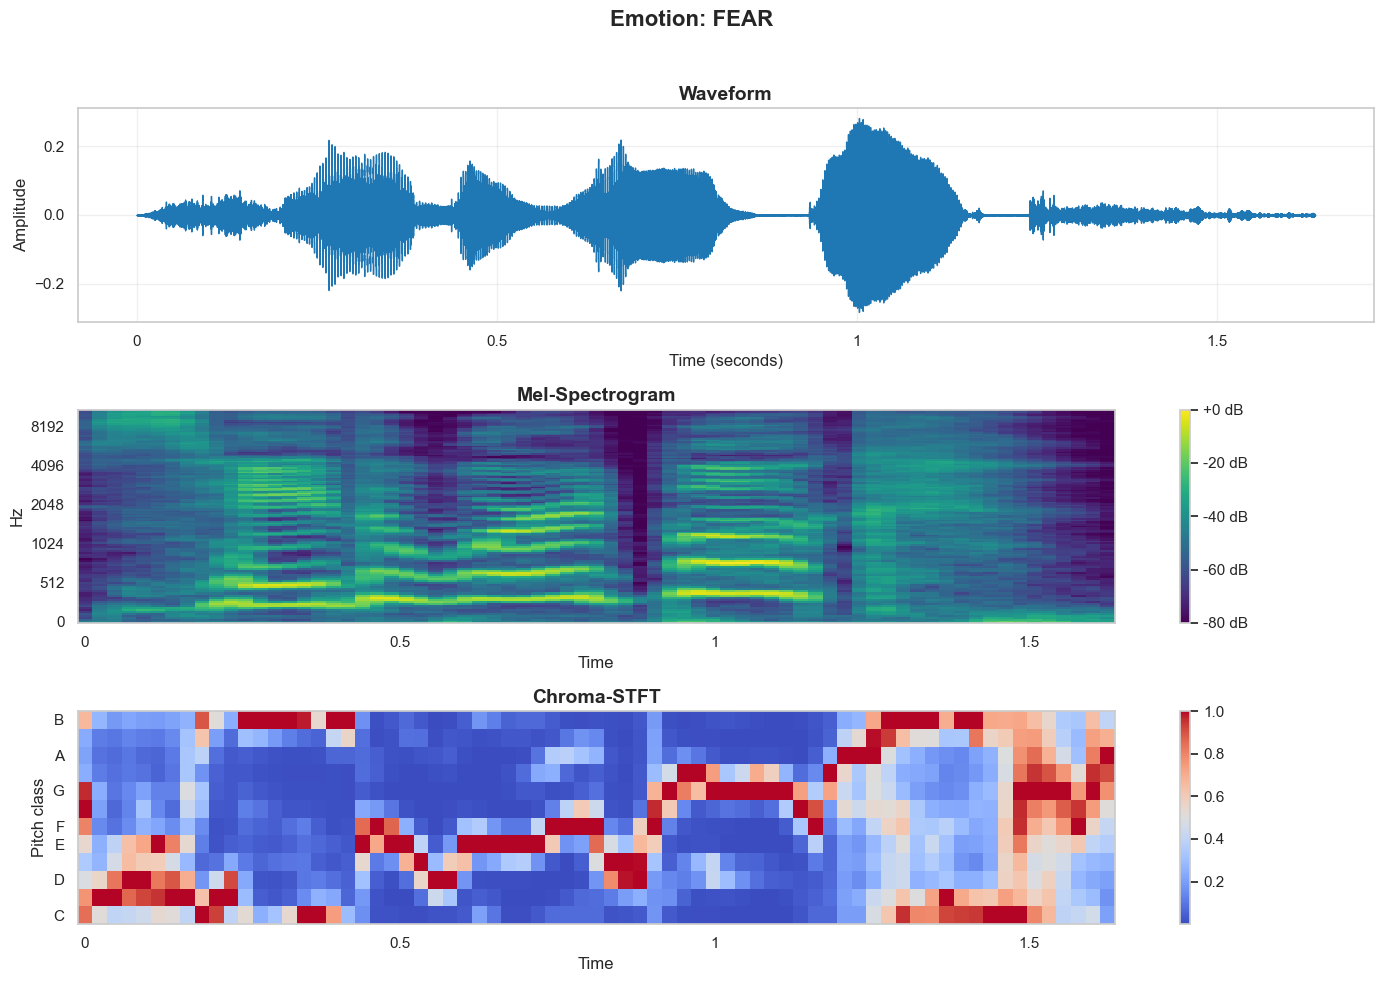

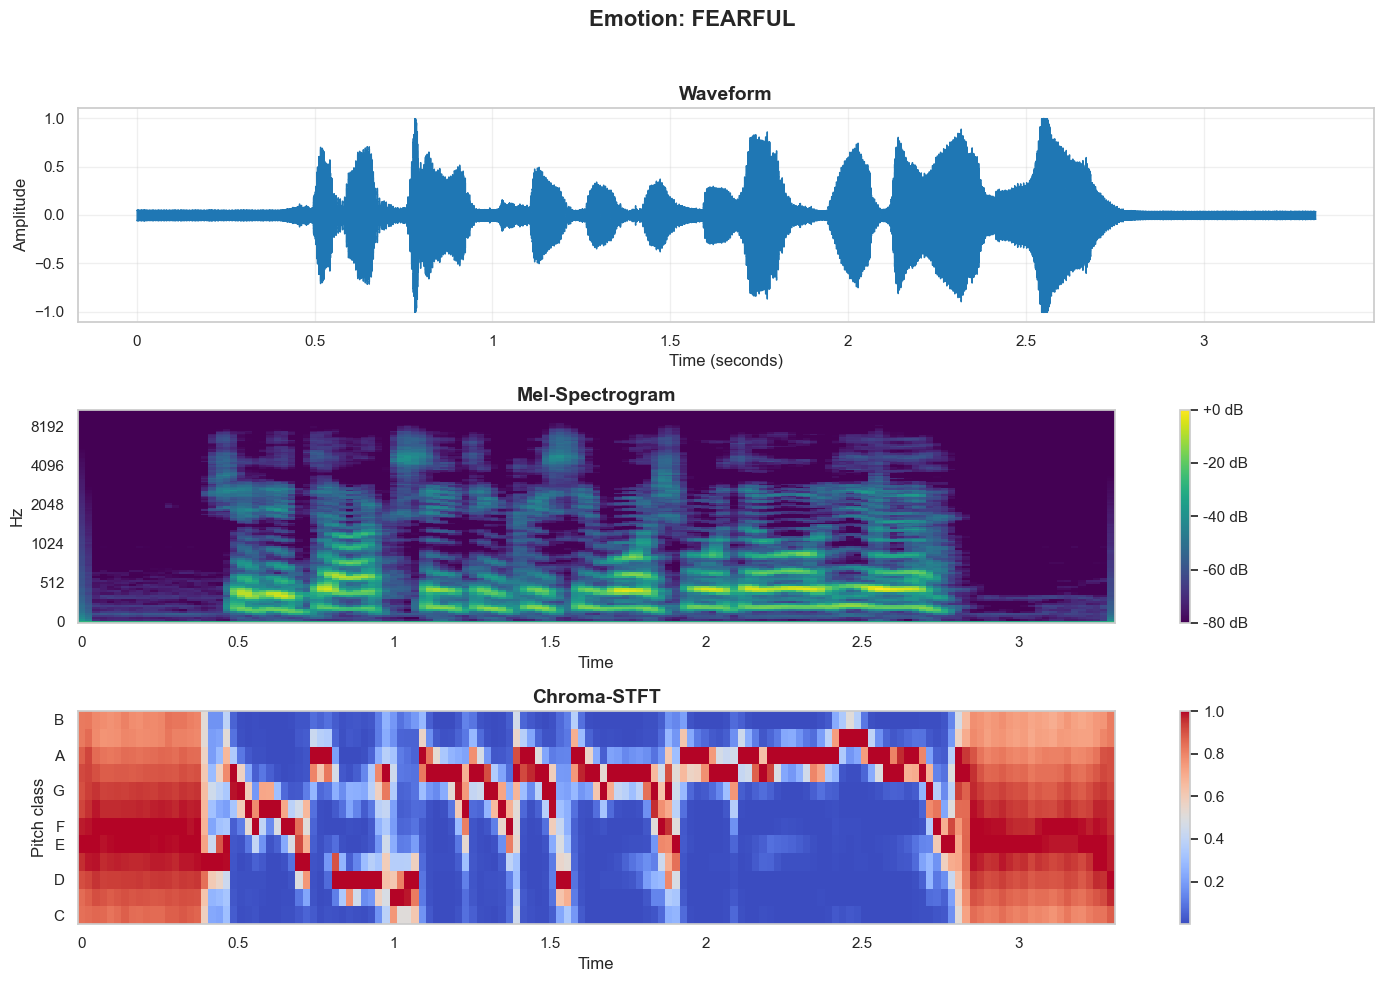

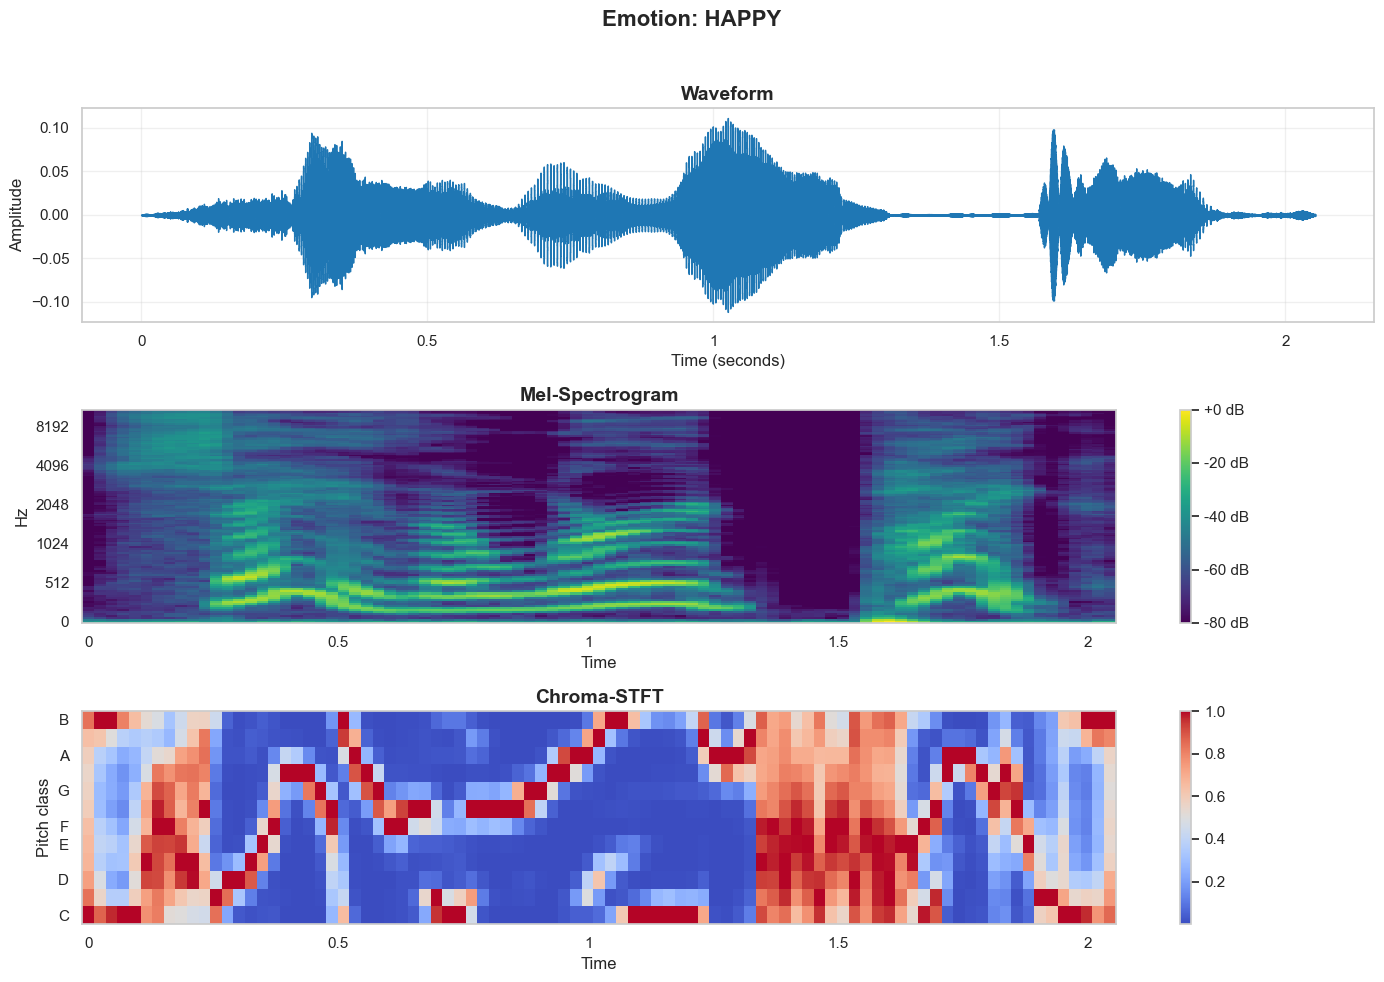

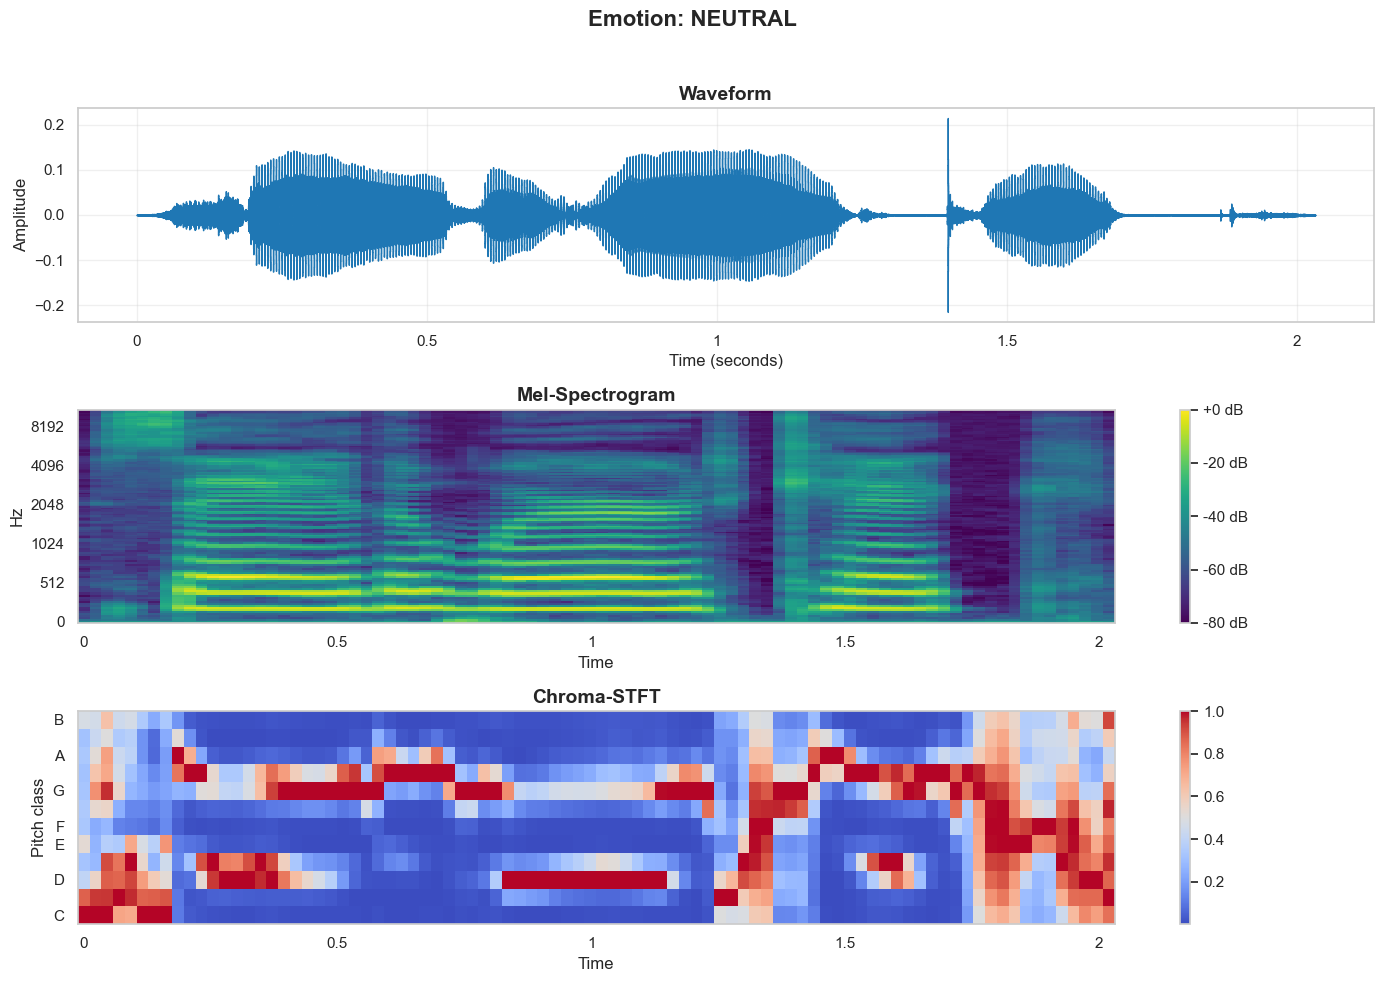

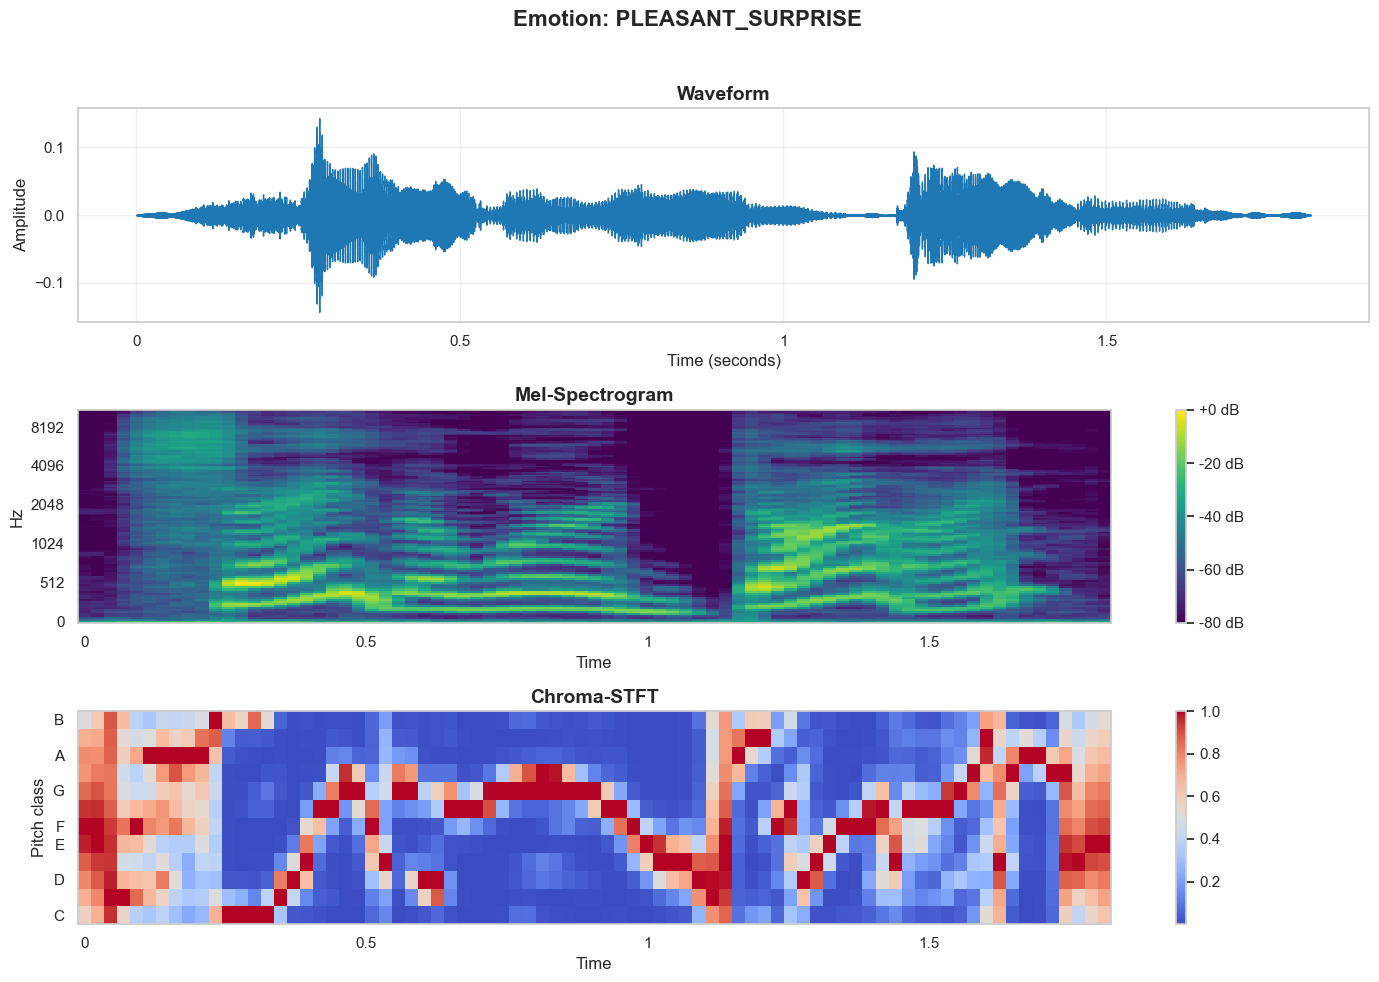

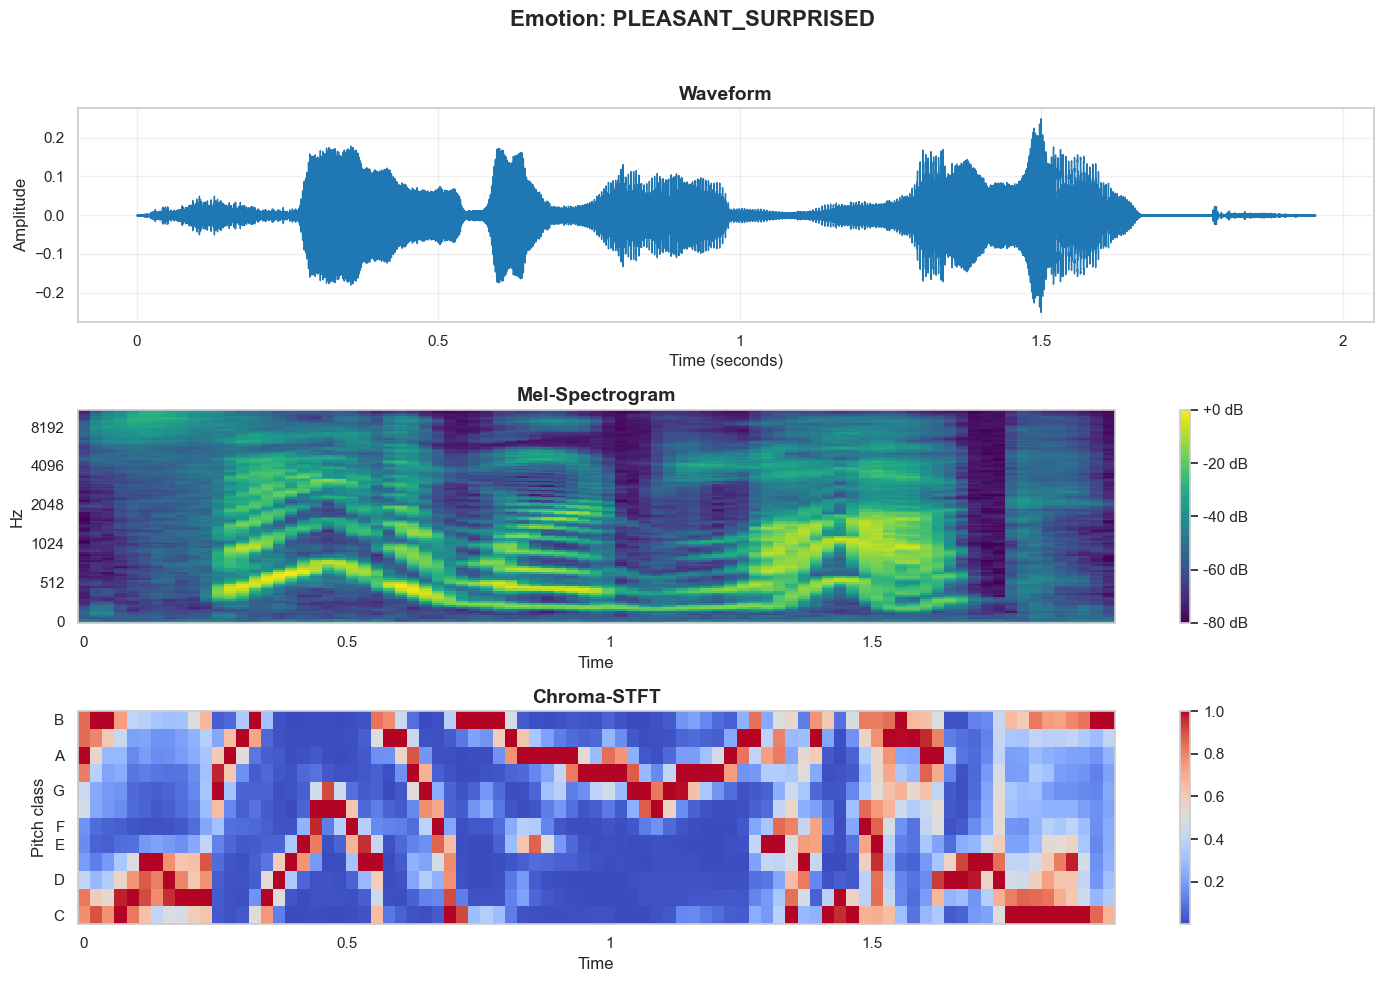

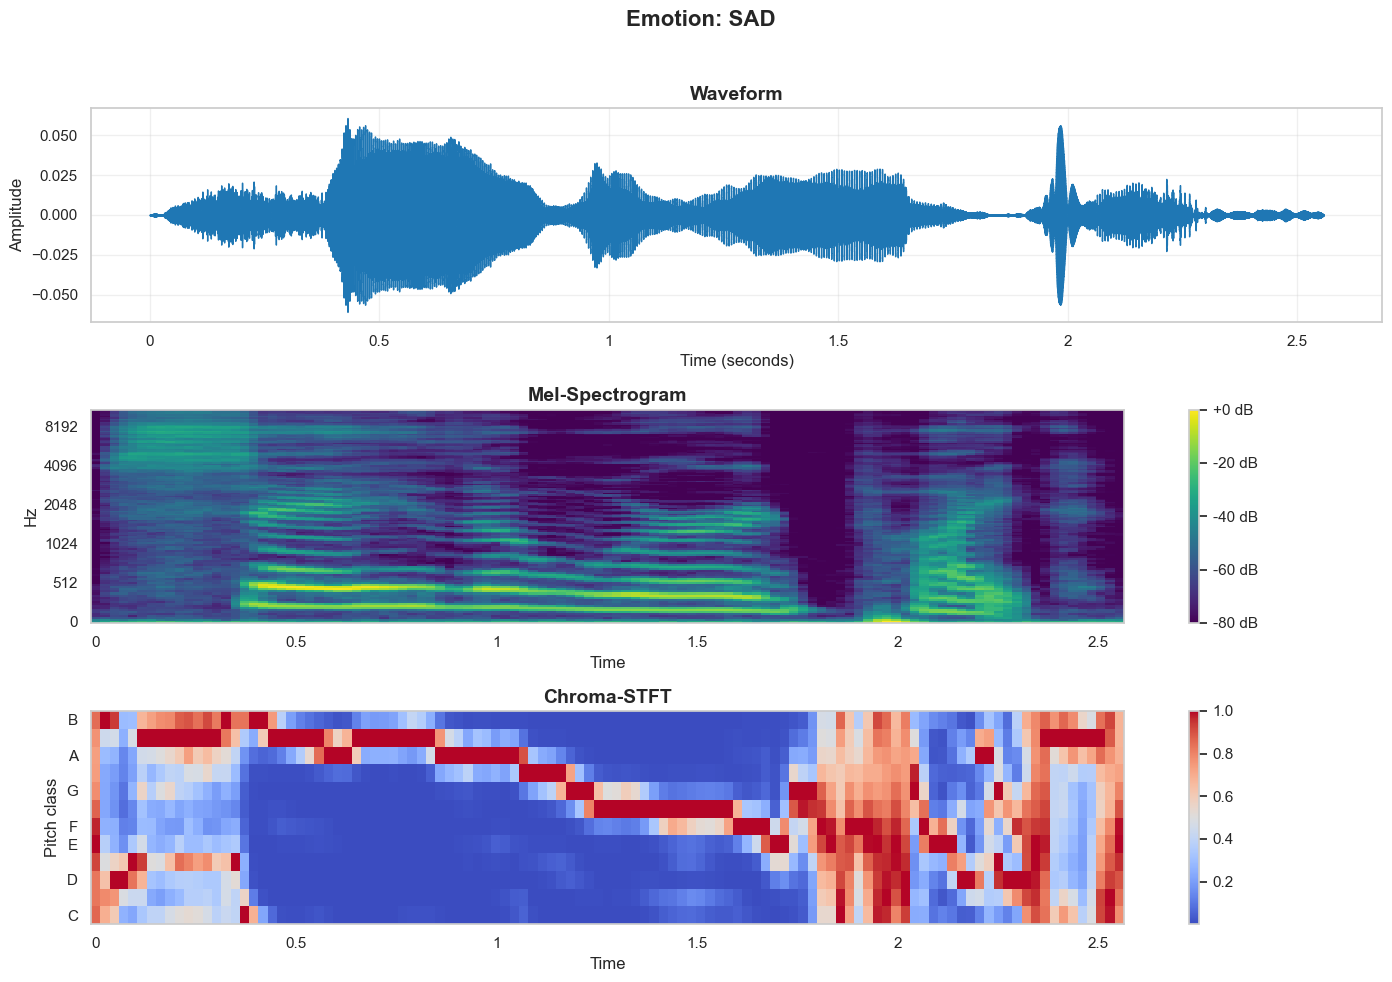

In [20]:
def compute_duration_if_missing(df):
    if 'duration_sec' not in df.columns:
        durations = []
        for p in df['paths']:
            try:
                y, sr = librosa.load(p, sr=None)
                durations.append(librosa.get_duration(y=y, sr=sr))
            except:
                durations.append(np.nan)
        df['duration_sec'] = durations
    return df

def get_mean_pitch_simple(path, sr=22050, fmin=50, fmax=500):
    try:
        y, sr = librosa.load(path, sr=sr)
        f0 = librosa.yin(y, fmin=fmin, fmax=fmax, sr=sr)
        f0 = f0[~np.isnan(f0)]
        return float(np.mean(f0)) if f0.size>0 else np.nan
    except:
        return np.nan

def compute_mean_pitch_if_missing(df):
    if 'mean_pitch' not in df.columns:
        df['mean_pitch'] = df['paths'].apply(lambda p: get_mean_pitch_simple(p))
    return df

def plot_and_play(path, emotion, sr=22050):
    try:
        y, sr = librosa.load(path, sr=sr)
    except Exception as e:
        print("Error loading:", path, e)
        return

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(f"Emotion: {emotion.upper()}", fontsize=16, fontweight='bold')

    plt.subplot(3,1,1)
    librosa.display.waveshow(y, sr=sr, color="#1f77b4")
    plt.title("Waveform", fontsize=14, fontweight='bold')
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)

    plt.subplot(3,1,2)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', cmap="viridis")
    plt.colorbar(format="%+2.0f dB")
    plt.title("Mel-Spectrogram", fontsize=14, fontweight='bold')

    plt.subplot(3,1,3)
    C = librosa.feature.chroma_stft(y=y, sr=sr)
    librosa.display.specshow(C, sr=sr, x_axis='time', y_axis='chroma', cmap="coolwarm")
    plt.colorbar()
    plt.title("Chroma-STFT", fontsize=14, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    display(Audio(y, rate=sr))

emotion_data = compute_duration_if_missing(emotion_data)
emotion_data = compute_mean_pitch_if_missing(emotion_data)

classes = sorted(emotion_data['emotions'].unique())

summary_rows = []
for emo in classes:
    subset = emotion_data[emotion_data['emotions'] == emo]
    summary_rows.append({
        'Emotion': emo,
        'Files': len(subset),
        'Mean Duration (s)': round(subset['duration_sec'].mean(), 2),
        'Mean Pitch (Hz)': round(subset['mean_pitch'].mean(), 2),
        'Min Duration': round(subset['duration_sec'].min(), 2),
        'Max Duration': round(subset['duration_sec'].max(), 2)
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

plt.figure(figsize=(10,5))
plt.bar(summary_df['Emotion'], summary_df['Files'], color="#7a5195")
plt.title("Combined Dataset: Number of Files per Emotion", fontsize=16, fontweight='bold')
plt.xlabel("Emotion")
plt.ylabel("File Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

for emo in classes:
    sample_row = emotion_data[emotion_data['emotions']==emo].sample(n=1, random_state=42).iloc[0]
    plot_and_play(sample_row['paths'], emo)